In [79]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from pathlib import Path
from PIL import Image
import numpy as np
from matplotlib.ticker import MaxNLocator

In [80]:
train_data = pd.read_csv("../data/train.csv")
train_data.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [81]:
train_data = train_data.drop("sample_id",axis=1)

In [82]:
meta_cols = [
    "image_path", "Sampling_Date", "State", "Species",
    "Pre_GSHH_NDVI", "Height_Ave_cm"
]

pivoted_train = train_data.pivot_table(
    index=[col for col in meta_cols],
    columns="target_name",
    values="target"
).reset_index()

pivoted_train.head()


target_name,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605


In [83]:
len(pivoted_train)

357

Ok, we loaded and pivoted the data. Looks like we have 357 images in total.

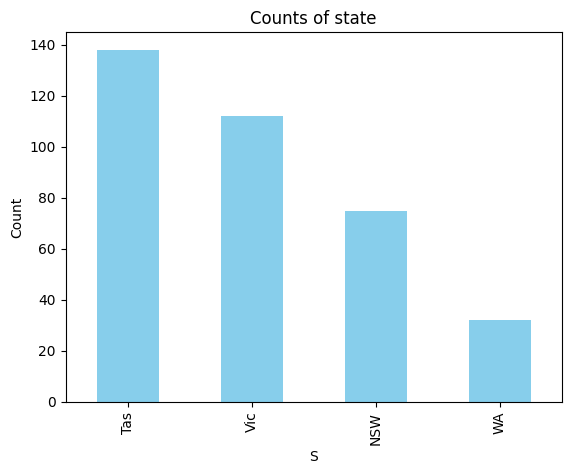

In [84]:
counts = pivoted_train["State"].value_counts()
counts.plot(kind='bar', color='skyblue')
plt.xlabel('S')
plt.ylabel('Count')
plt.title('Counts of state')
plt.show()

Seems like the states are not distributed evenly across all images.

In [85]:
counts = pivoted_train["Species"].value_counts()
counts

Species
Ryegrass_Clover                                                98
Ryegrass                                                       62
Phalaris_Clover                                                42
Clover                                                         41
Fescue                                                         28
Lucerne                                                        22
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed    11
Fescue_CrumbWeed                                               10
WhiteClover                                                    10
Phalaris                                                        8
Phalaris_Ryegrass_Clover                                        8
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass                 7
SubcloverLosa                                                   5
SubcloverDalkeith                                               3
Mixed                                                           2
Na

In [86]:
counts["Phalaris_SilverGrass"] = counts["Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed"]
counts["Phalaris_BromeGrass"] = counts["Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass"]


In [87]:
del counts["Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed"]
del counts["Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass"]
# cut down on very long names

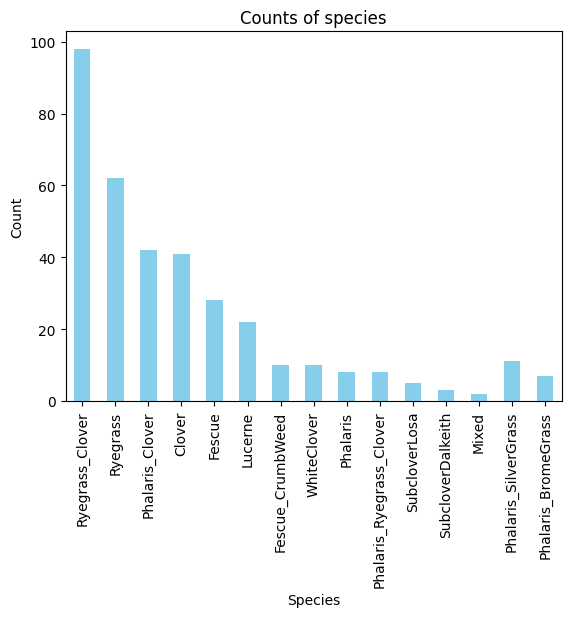

In [88]:
counts.plot(kind='bar', color='skyblue')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Counts of species')
plt.show()

Which species is in the image is also not distributed evenly. A very small proportion of images are "mixed".

In [123]:
def plot_counts(var, top_n=50):
    plt.figure(figsize=(10, 6))
    counts = pivoted_train[var].value_counts().head(top_n)
    counts.index = counts.index.astype(str)
    counts.plot(kind='bar', color='blue', width=0.8)
    plt.xlabel(f'{var} value')
    plt.ylabel('Count')
    plt.title(f'Top {top_n} Counts of {var}')

    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

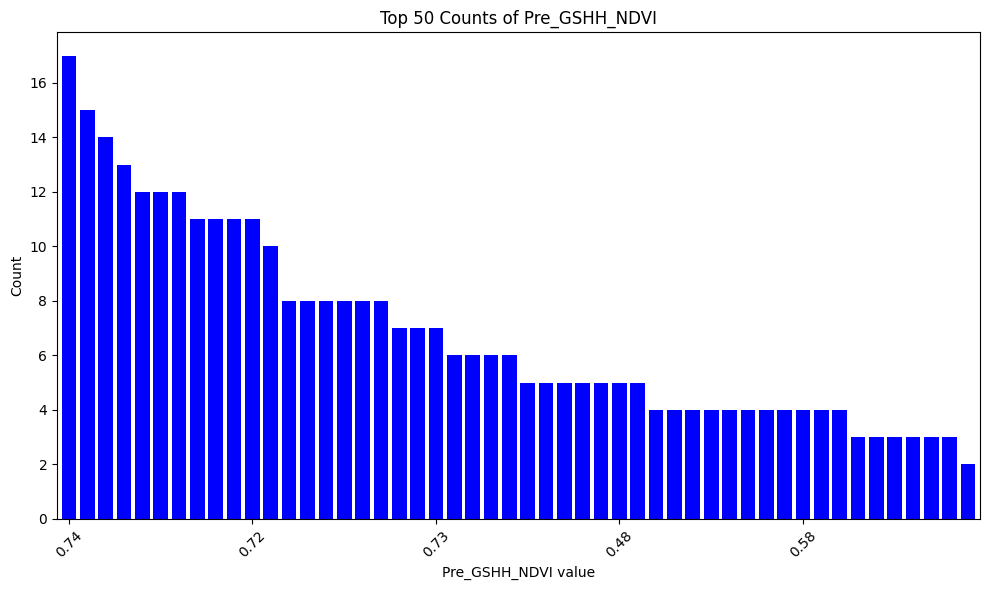

In [124]:
plot_counts("Pre_GSHH_NDVI")

Seems like this variable is evenly divided.

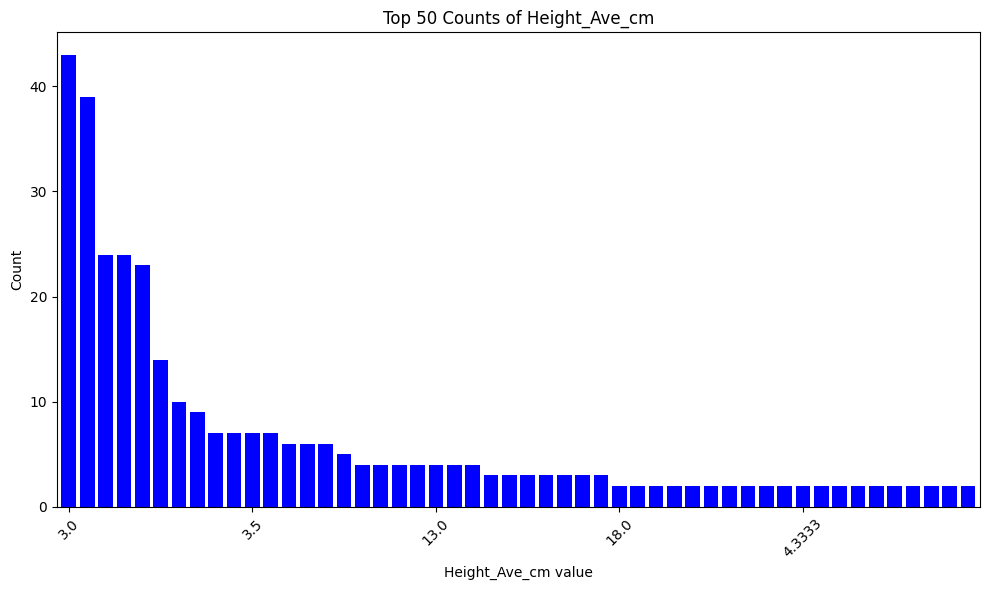

In [125]:
plot_counts("Height_Ave_cm")

Seems like most of the values for height_ave_cm, peak around 3.0

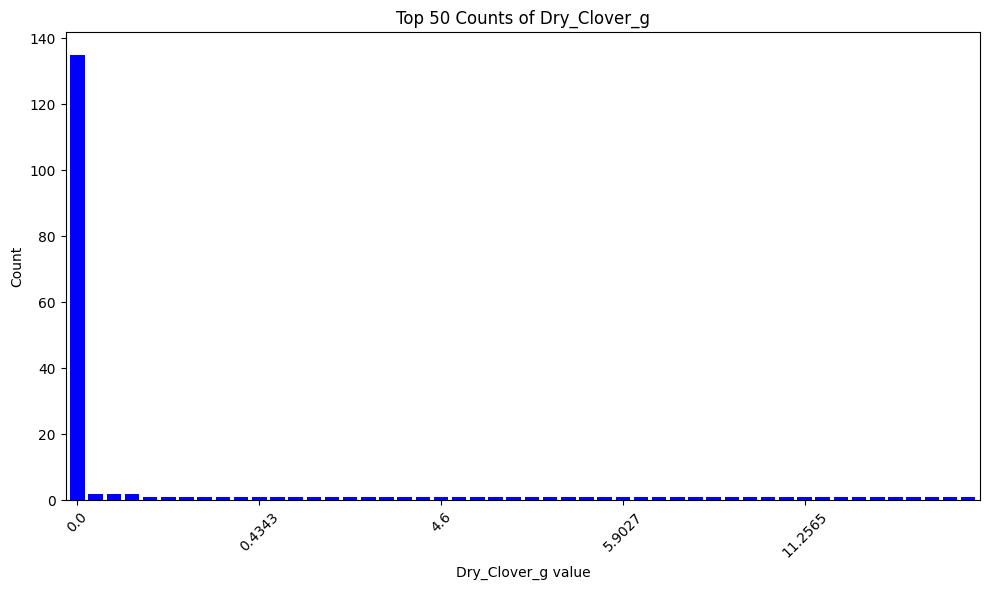

In [126]:
plot_counts("Dry_Clover_g")

In most images, there is almost no dry clover! Interesting.

In [128]:
counts = pivoted_train["Dry_Clover_g"].value_counts()
np.max(counts)

np.int64(135)

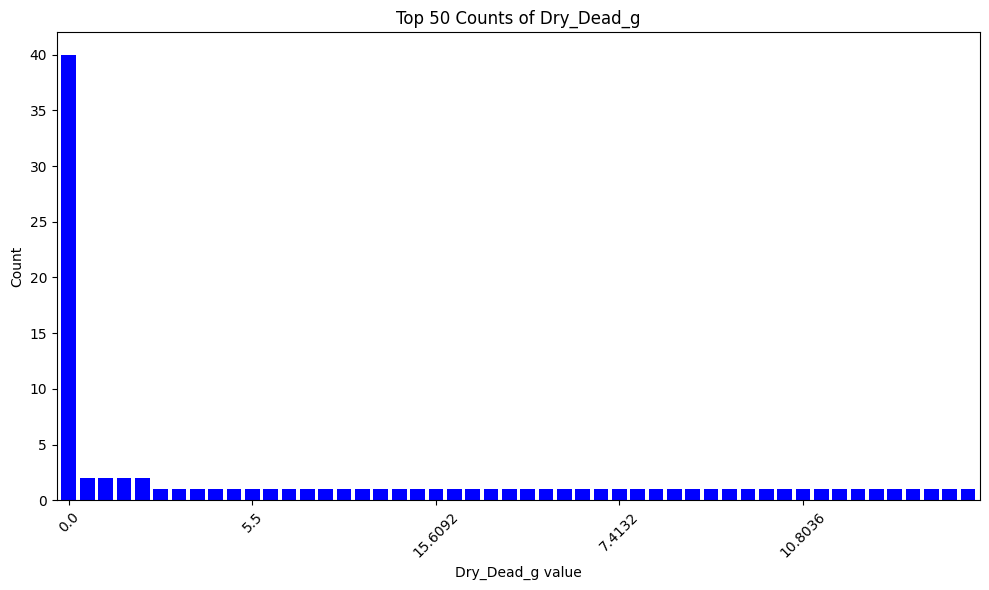

In [129]:
plot_counts("Dry_Dead_g")

Same with dry_dead_g

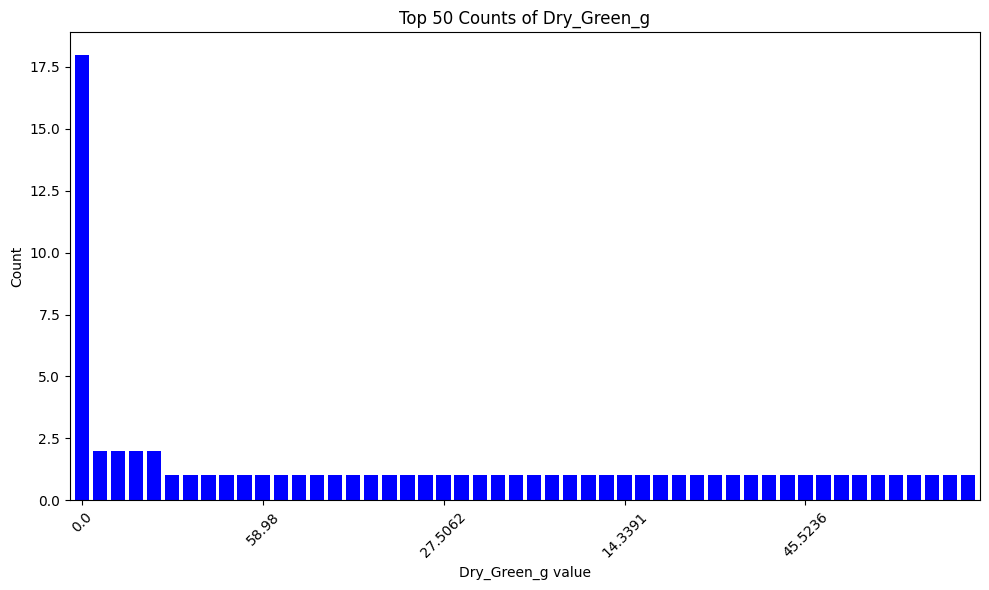

In [130]:
plot_counts("Dry_Green_g")

Same with dry green g

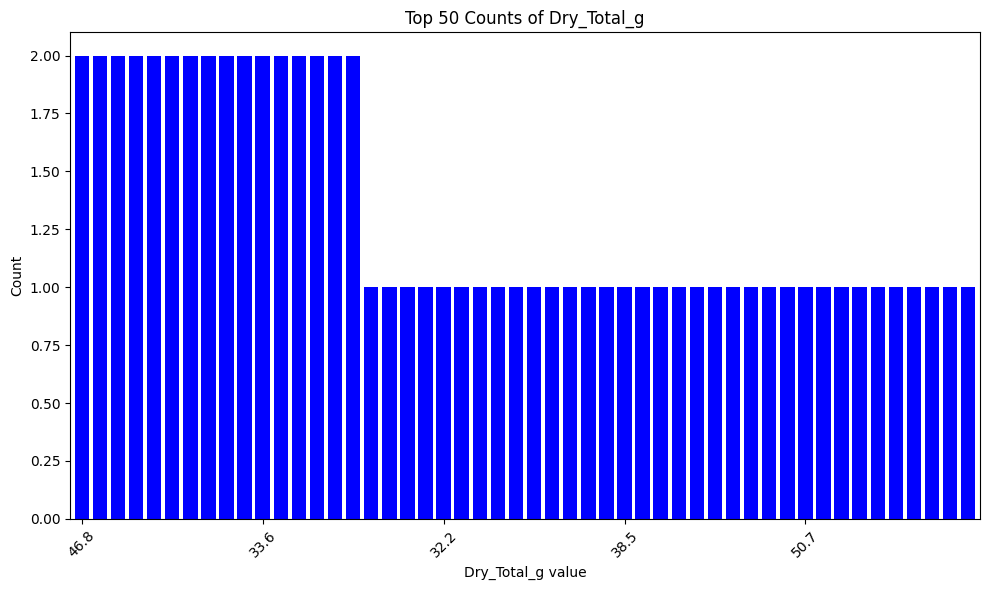

In [131]:
plot_counts("Dry_Total_g")

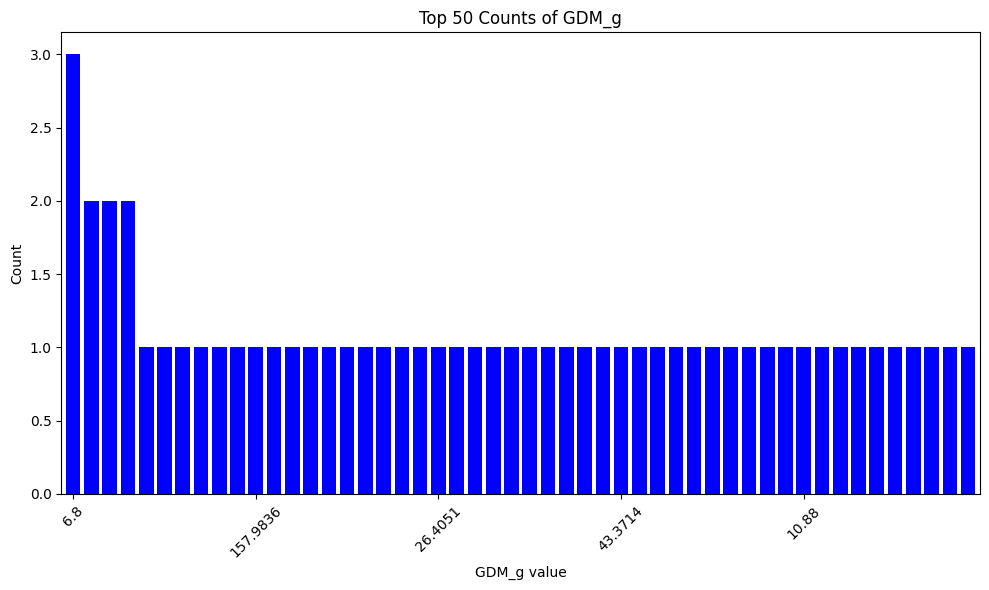

In [132]:
plot_counts("GDM_g")

Overall, for all of the target variables, most of the time there is most of one target variable, and less of others.

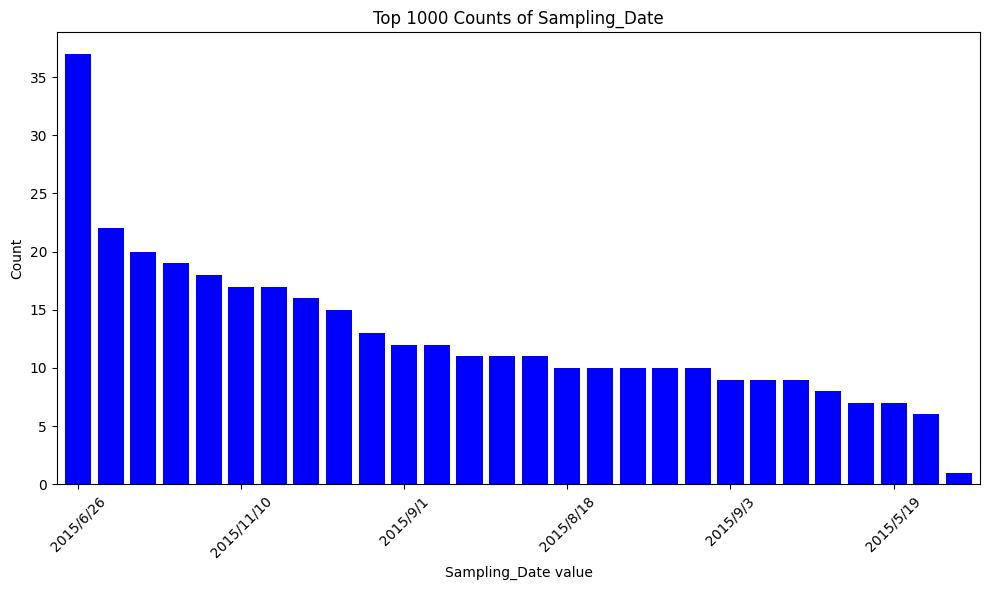

In [152]:
plot_counts("Sampling_Date", top_n=1000)

Dates seem distributed, but one day (2015/6/26) seems more popular.

In [133]:
sub_train = pivoted_train[[
                        #    "Sampling_Date",
                        #    "State",
                        #    "Species",
                           "Pre_GSHH_NDVI",
                           "Height_Ave_cm",
                           "Dry_Clover_g",
                           "Dry_Dead_g",
                           "Dry_Green_g",
                           "Dry_Total_g",
                           "GDM_g",
                           ]
                           ]

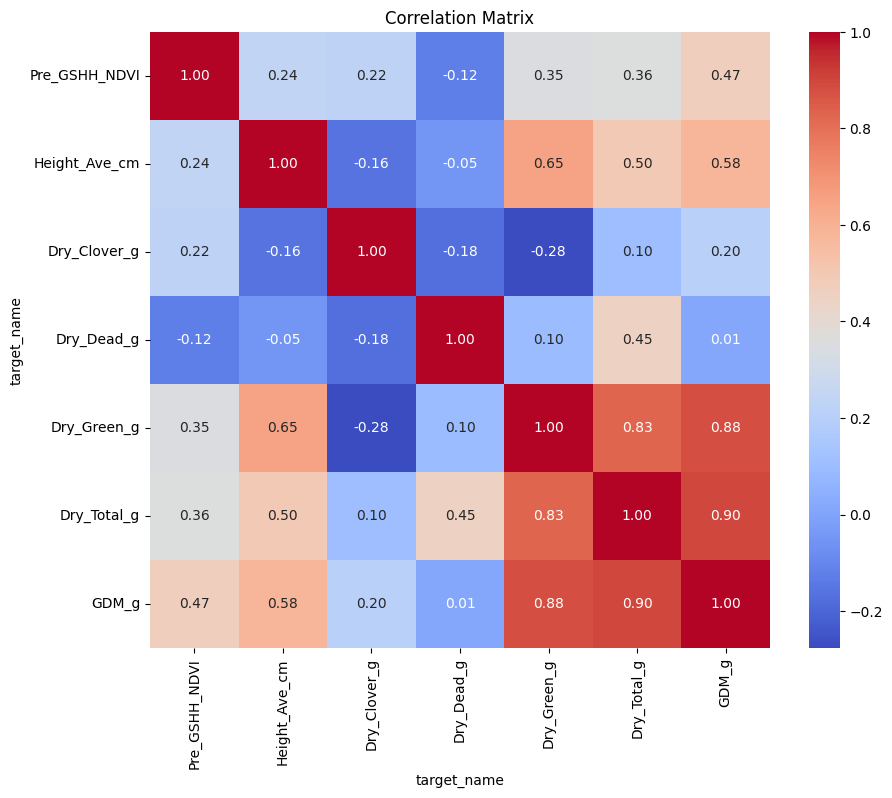

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

This is interesting, but is a bit misguiding since some of the features are specifically combinations of other features. Lets take a look at a more refined correlation matrix.

In [49]:
sub_train = pivoted_train[[
                        #    "Sampling_Date",
                        #    "State",
                        #    "Species",
                           "Dry_Clover_g",
                           "Dry_Dead_g",
                           "Dry_Green_g",
                           ]
                           ]

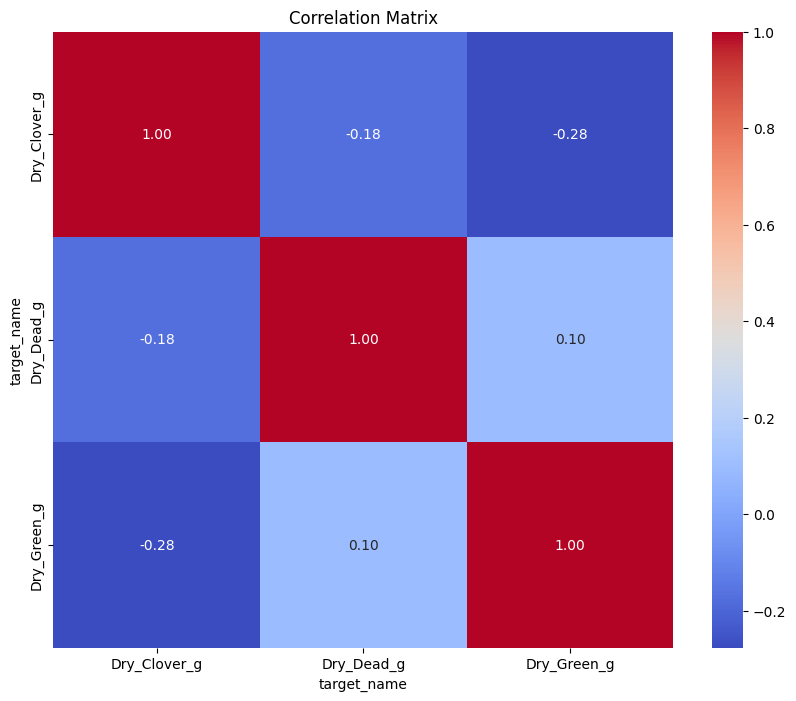

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

These features are not combination of other features, they are all indepedant measurements.
Interestingly, Dry clovers and Dry green are negativley correlated. Perhaps a patch of grass seems to mainly contain one kind of foilage.
The dead dry soil is negativley correlated with clovers, but positivley corellated with green grass.
Perhaps this says something about the growing conditions of the two plant species.

## Images

Now on to the images:

In [ ]:
data_path_img = Path("../data/train")
img_paths = list(data_path_img.rglob("*.jpg"))
print(f"found {len(img_paths)} images")

Found 357 images


In [138]:
all_pixels = []

for img_path in img_paths:
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)  # shape: (H, W, C)
    all_pixels.append(arr.flatten())

all_pixels = np.concatenate(all_pixels)

In [139]:
def plot_pixel_distribution(all_pixels, title="", median=None):
    plt.figure(figsize=(8,5))
    plt.hist(all_pixels, bins=50, color='blue', edgecolor='black', density=True)
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")

    if median is not None:
        plt.axvline(median, color='red', linestyle='dashed', linewidth=2, 
                    label=f'Median: {median:.2f}')
        plt.legend()

    plt.title(f"Pixel value distribution in train set | {title}")
    plt.tight_layout()
    plt.show()

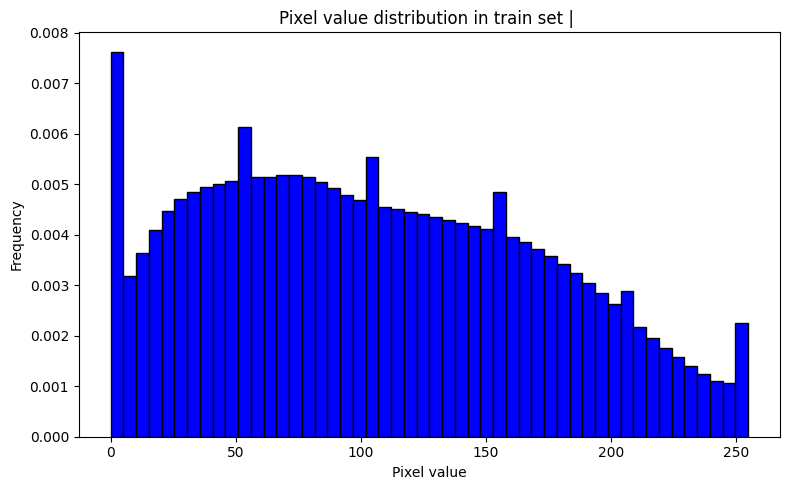

In [54]:
plot_pixel_distribution(all_pixels)

Interesting, seems spread out, but with certain peaks. Lets look per state.

In [140]:
def plot_pixel_per_state(train_inp, state):
    imgs_pivot = train_inp[train_inp["State"] == state]
    imgs = imgs_pivot["image_path"]

    all_pixels_state = []
    for img_path in img_paths:
        fname = f"train/{img_path.stem}.jpg"
        if imgs.str.contains(fname).any():
            img = Image.open(img_path).convert("RGB")
            arr = np.array(img)  # shape: (H, W, C)
            all_pixels_state.append(arr.flatten())

    all_pixels_state = np.concatenate(all_pixels_state)
    state_median = np.median(all_pixels_state)
    return all_pixels_state, state_median

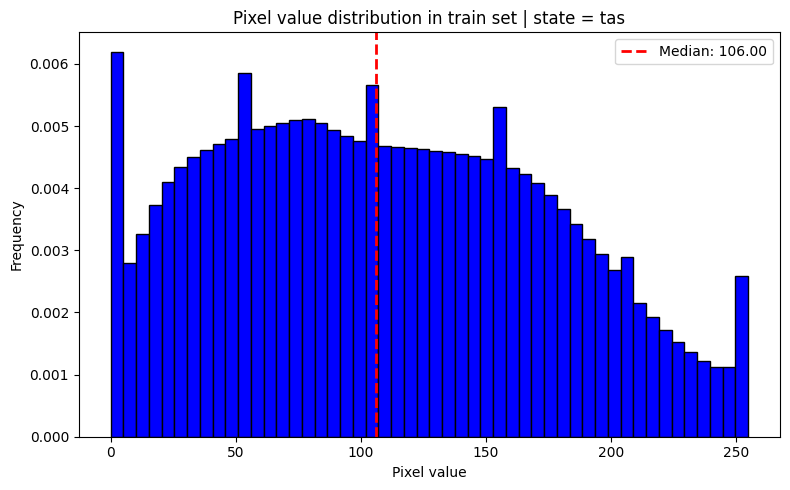

In [141]:
all_pixels_tas, median = plot_pixel_per_state(pivoted_train, "Tas")
plot_pixel_distribution(all_pixels_tas, title="state = tas", median=median)

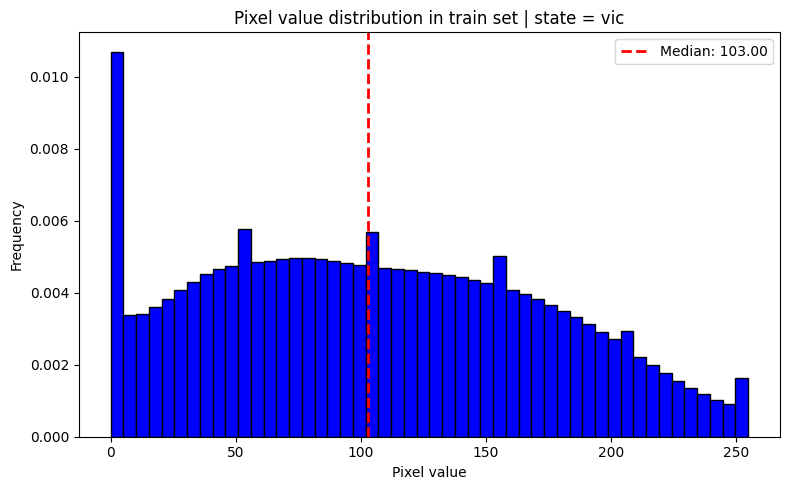

In [142]:
all_pixels_vic, median = plot_pixel_per_state(pivoted_train, "Vic")
plot_pixel_distribution(all_pixels_vic, title="state = vic", median=median)

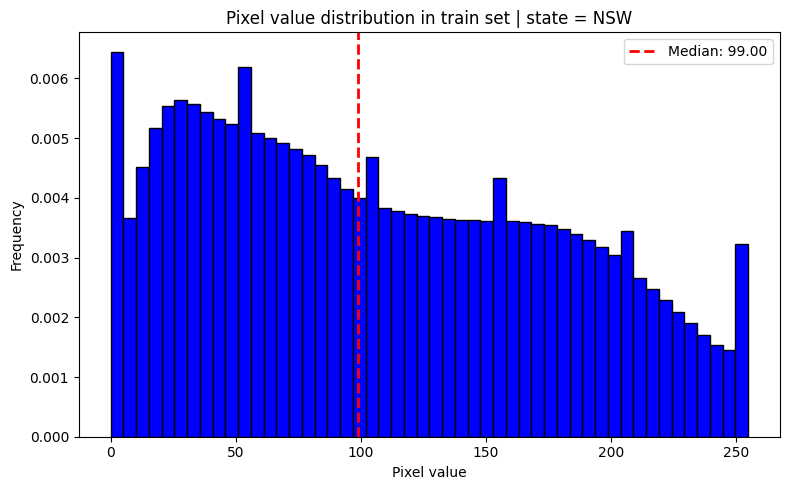

In [143]:
all_pixels_wa, median = plot_pixel_per_state(pivoted_train, "NSW")
plot_pixel_distribution(all_pixels_wa, title="state = NSW", median=median)

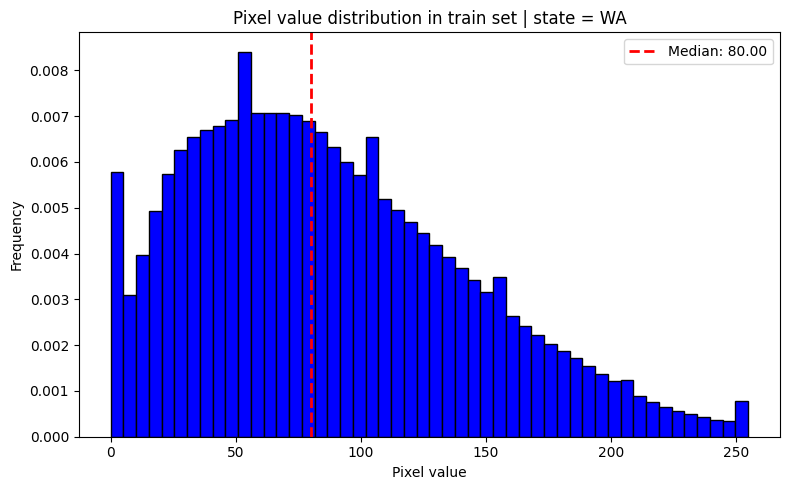

In [144]:
all_pixels_wa, median = plot_pixel_per_state(pivoted_train, "WA")
plot_pixel_distribution(all_pixels_wa, title="state = WA", median=median)

Based on the four different distributions, the images taken in different states have different distributions, this could be useful to the model. The median seems to be very similar, except for in the state WA, where it is a fair bit lower.

Lets look at some specific images

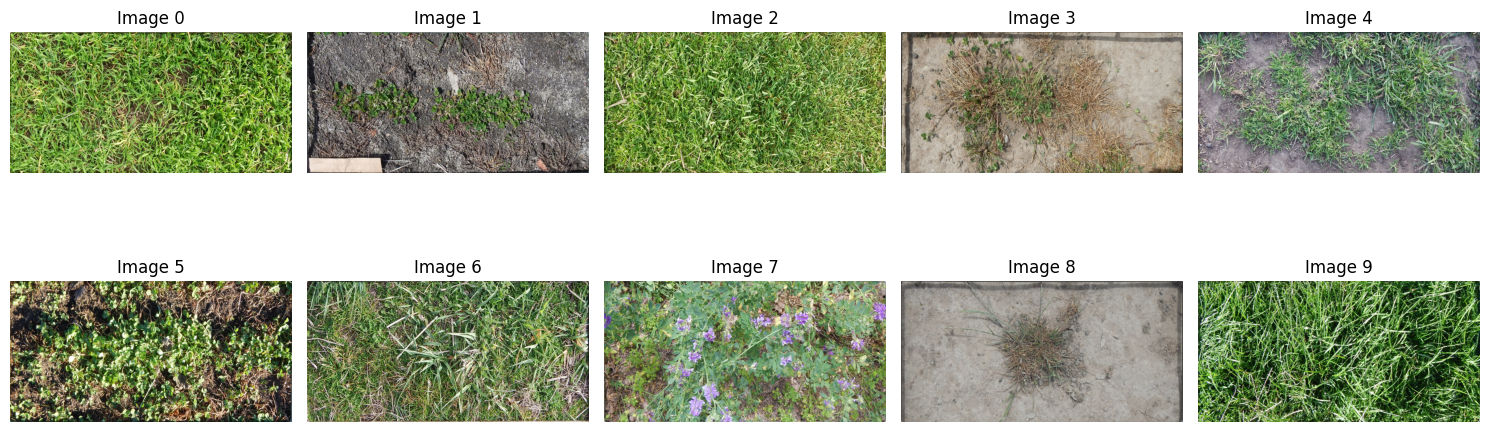

In [154]:
def plot_image_grid(img_paths, rows=2, cols=5):
    _fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        img = Image.open(img_paths[i]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"Image {i}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_image_grid(img_paths)

They look somewhat varied